# Detección de Fraude con Tarjetas de Crédito — Proyecto MLOps
**Software Inteligente (UNMSM, Ciclo 9) — Semana 14**

El notebook se construye por fases, siguiendo el ciclo de vida de MLOps. Cada sección corresponde a una etapa y se amplía conforme avanza el proyecto:

- **Fase 1 — Data (sección actual):** exploración del dataset (EDA). Se cargan los datos, se revisa su calidad, y se analizan el desbalance de clases, el comportamiento del monto y las correlaciones con el fraude.
- **Fase 2 — Modeling:** entrenamiento y comparación de modelos *(se añadirá más adelante)*.
- **Fase 3 — Tracking con MLflow:** registro de experimentos y del modelo *(se añadirá más adelante)*.
- **Fase 4 — Deployment:** despliegue y validación del modelo *(se añadirá más adelante)*.

---
# FASE 1 — Análisis Exploratorio de Datos (EDA)

## 0. Configuración

Se importan las librerías utilizadas a lo largo del notebook y se prepara la carpeta `reports/`, donde se guardan los gráficos generados.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Estilo de gráficos
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

# Carpeta para guardar los gráficos que irán al informe (/reports)
REPORTS_DIR = 'reports'
os.makedirs(REPORTS_DIR, exist_ok=True)

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 1. Carga del dataset

Se carga el archivo `creditcard.csv`. La celda lo busca de forma automática: en entorno local se toma de la carpeta del proyecto; en Google Colab se monta el Drive y se lee desde ahí (al ejecutar, Colab solicita autorizar el montaje).

In [2]:
# Se detecta si el entorno de ejecución es Google Colab
try:
    import google.colab  # noqa
    EN_COLAB = True
except ImportError:
    EN_COLAB = False

# Se busca el CSV en la carpeta del proyecto (entorno local)
rutas = ['creditcard.csv', 'data/creditcard.csv', '../creditcard.csv']
ruta_csv = next((r for r in rutas if os.path.exists(r)), None)

# Si el entorno es Colab y no se halló en local, se monta Google Drive y se lee desde ahí
if ruta_csv is None and EN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    rutas_drive = [
        '/content/drive/MyDrive/octavo/creditcard.csv',
        '/content/drive/MyDrive/creditcard.csv',
    ]
    ruta_csv = next((r for r in rutas_drive if os.path.exists(r)), None)

assert ruta_csv is not None, (
    'No se encontró creditcard.csv. En Colab debe ubicarse en Google Drive; '
    'en entorno local, en la carpeta del proyecto.'
)
print(f'Cargando desde: {ruta_csv}')
df = pd.read_csv(ruta_csv)
print('Dataset cargado.')

Cargando desde: creditcard.csv
Dataset cargado.


## 2. Descripción y calidad de los datos

Se revisan el tamaño del dataset y los tipos de dato, y se comprueba con código la existencia de valores nulos o filas duplicadas antes de continuar.

In [3]:
print(f'Filas x Columnas: {df.shape[0]:,} x {df.shape[1]}')
print(f'\nColumnas: {list(df.columns)}')
df.head()

Filas x Columnas: 284,807 x 31

Columnas: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
# Tipos de datos y memoria
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
# ---- Valores nulos (demostrado con código) ----
nulos_totales = df.isnull().sum().sum()
print(f'Total de valores nulos en todo el dataset: {nulos_totales}')
if nulos_totales == 0:
    print('=> No hay valores faltantes. El dataset está completo.')
else:
    print(df.isnull().sum()[df.isnull().sum() > 0])

Total de valores nulos en todo el dataset: 0
=> No hay valores faltantes. El dataset está completo.


In [6]:
# ---- Filas duplicadas (demostrado con código) ----
n_dup = df.duplicated().sum()
print(f'Filas duplicadas exactas: {n_dup:,}')
print(f'Porcentaje del total: {n_dup / len(df) * 100:.3f}%')

Filas duplicadas exactas: 1,081
Porcentaje del total: 0.380%


In [7]:
# El análisis se realiza sobre el dataset sin duplicados exactos
filas_antes = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f'Filas antes: {filas_antes:,}  ->  Filas después: {len(df):,}')
print(f'Duplicados eliminados: {filas_antes - len(df):,}')

Filas antes: 284,807  ->  Filas después: 283,726
Duplicados eliminados: 1,081


## 3. Distribución de la clase (`Class`)

Se cuantifican las transacciones fraudulentas y legítimas, en cantidad y en porcentaje, con el fin de dimensionar el desbalance del problema.

In [8]:
conteo = df['Class'].value_counts().sort_index()
porcentaje = df['Class'].value_counts(normalize=True).sort_index() * 100

resumen_clase = pd.DataFrame({
    'Clase': ['0 - Legítima', '1 - Fraude'],
    'Cantidad': conteo.values,
    'Porcentaje (%)': porcentaje.round(3).values
})
print(resumen_clase.to_string(index=False))

n_fraude = int(conteo[1]); n_legit = int(conteo[0])
print(f'\n=> 1 fraude por cada ~{n_legit // n_fraude} transacciones legítimas.')

       Clase  Cantidad  Porcentaje (%)
0 - Legítima    283253          99.833
  1 - Fraude       473           0.167

=> 1 fraude por cada ~598 transacciones legítimas.


/var/folders/0n/v1yd2rdn1ql9k06k_tv9f8cc0000gn/T/ipykernel_84706/3537669978.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, ax=axes[0], palette=['#2e86de', '#e74c3c'])
/var/folders/0n/v1yd2rdn1ql9k06k_tv9f8cc0000gn/T/ipykernel_84706/3537669978.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Legítima (0)', 'Fraude (1)'])
/var/folders/0n/v1yd2rdn1ql9k06k_tv9f8cc0000gn/T/ipykernel_84706/3537669978.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, ax=axes[1], palette=['#2e86de', '#e74c3c'])
/var/folders/0n/v1yd2rdn1ql9k06k_tv9f8cc0

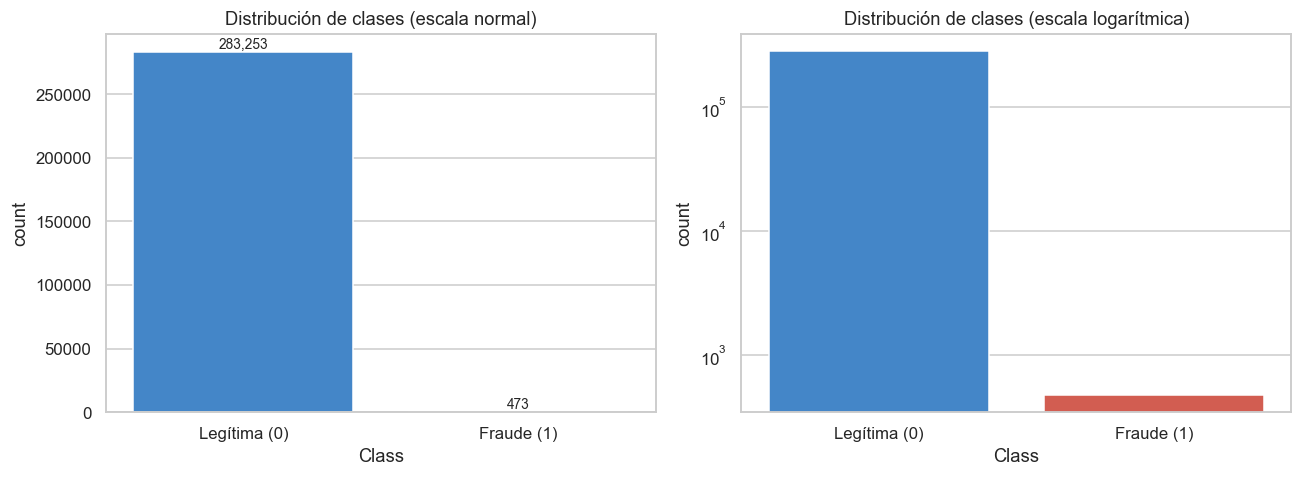

Gráfico guardado en /reports/01_desbalance_clases.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Escala normal (se ve lo extremo del desbalance)
sns.countplot(x='Class', data=df, ax=axes[0], palette=['#2e86de', '#e74c3c'])
axes[0].set_title('Distribución de clases (escala normal)')
axes[0].set_xticklabels(['Legítima (0)', 'Fraude (1)'])
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)

# Escala logarítmica (permite ver la barra de fraude)
sns.countplot(x='Class', data=df, ax=axes[1], palette=['#2e86de', '#e74c3c'])
axes[1].set_yscale('log')
axes[1].set_title('Distribución de clases (escala logarítmica)')
axes[1].set_xticklabels(['Legítima (0)', 'Fraude (1)'])

plt.tight_layout()
plt.savefig(f'{REPORTS_DIR}/01_desbalance_clases.png', bbox_inches='tight')
plt.show()
print('Gráfico guardado en /reports/01_desbalance_clases.png')

## 4. Distribución del monto (`Amount`) por clase

Se compara el comportamiento del monto entre las transacciones legítimas y las fraudulentas, mediante estadísticas descriptivas, un boxplot y un histograma.

In [10]:
resumen_amount = df.groupby('Class')['Amount'].describe()[['mean', '50%', 'std', 'max']]
resumen_amount.index = ['Legítima (0)', 'Fraude (1)']
resumen_amount.columns = ['Media', 'Mediana', 'Desv. Est.', 'Máximo']
print('Estadísticas de Amount por clase:')
print(resumen_amount.round(2).to_string())

Estadísticas de Amount por clase:
               Media  Mediana  Desv. Est.    Máximo
Legítima (0)   88.41    22.00      250.38  25691.16
Fraude (1)    123.87     9.82      260.21   2125.87


/var/folders/0n/v1yd2rdn1ql9k06k_tv9f8cc0000gn/T/ipykernel_84706/1046767578.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y='Amount', data=df, ax=axes[0], palette=['#2e86de', '#e74c3c'])
/var/folders/0n/v1yd2rdn1ql9k06k_tv9f8cc0000gn/T/ipykernel_84706/1046767578.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Legítima (0)', 'Fraude (1)'])


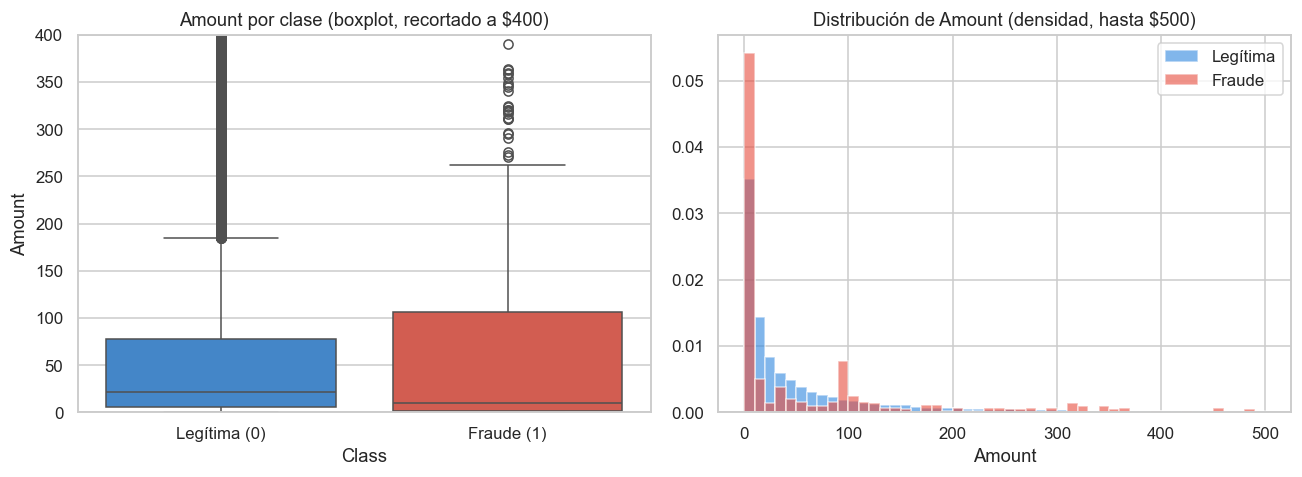

Gráfico guardado en /reports/02_amount_por_clase.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Boxplot de Amount por clase (recortamos eje Y para que sea legible)
sns.boxplot(x='Class', y='Amount', data=df, ax=axes[0], palette=['#2e86de', '#e74c3c'])
axes[0].set_ylim(0, 400)
axes[0].set_title('Amount por clase (boxplot, recortado a $400)')
axes[0].set_xticklabels(['Legítima (0)', 'Fraude (1)'])

# Histogramas superpuestos
axes[1].hist(df[df.Class == 0]['Amount'], bins=50, range=(0, 500), alpha=0.6, label='Legítima', color='#2e86de', density=True)
axes[1].hist(df[df.Class == 1]['Amount'], bins=50, range=(0, 500), alpha=0.6, label='Fraude', color='#e74c3c', density=True)
axes[1].set_title('Distribución de Amount (densidad, hasta $500)')
axes[1].set_xlabel('Amount'); axes[1].legend()

plt.tight_layout()
plt.savefig(f'{REPORTS_DIR}/02_amount_por_clase.png', bbox_inches='tight')
plt.show()
print('Gráfico guardado en /reports/02_amount_por_clase.png')

## 5. Matriz de correlación

Se calcula la correlación entre todas las variables y se identifican las que más se relacionan con `Class`. Se muestra primero el mapa de calor completo y, a continuación, un ranking con las variables más correlacionadas con el fraude.

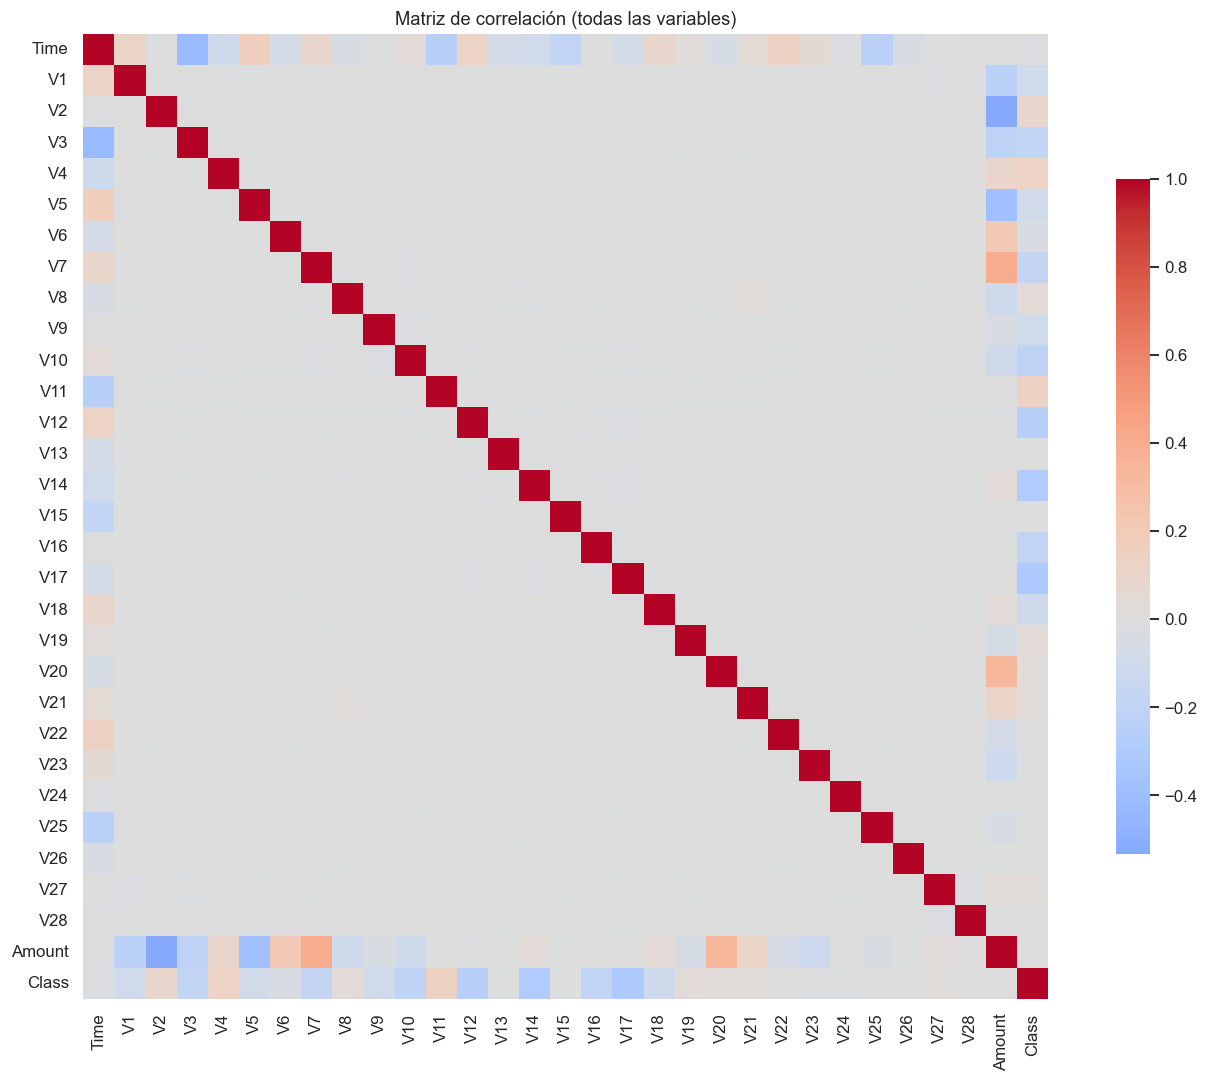

Gráfico guardado en /reports/03_matriz_correlacion.png


In [12]:
corr = df.corr()

plt.figure(figsize=(13, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, square=True,
            cbar_kws={'shrink': 0.7}, xticklabels=True, yticklabels=True)
plt.title('Matriz de correlación (todas las variables)')
plt.tight_layout()
plt.savefig(f'{REPORTS_DIR}/03_matriz_correlacion.png', bbox_inches='tight')
plt.show()
print('Gráfico guardado en /reports/03_matriz_correlacion.png')

Top 10 variables más correlacionadas con el fraude (Class):
V17   -0.313
V14   -0.293
V12   -0.251
V10   -0.207
V16   -0.187
V3    -0.182
V7    -0.172
V11    0.149
V4     0.129
V18   -0.105


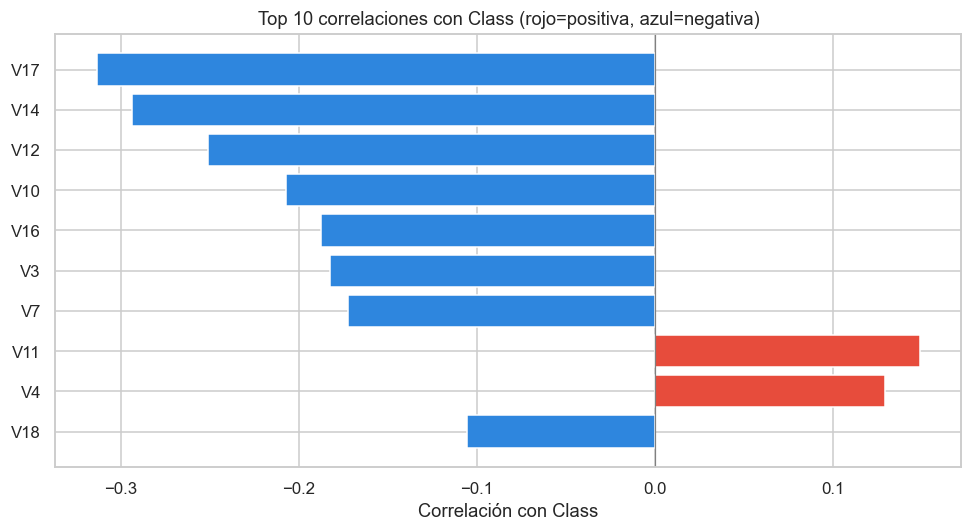

Gráfico guardado en /reports/04_top_correlaciones.png


In [13]:
# Ranking: variables más correlacionadas con Class (valor absoluto)
corr_class = corr['Class'].drop('Class').sort_values(key=abs, ascending=False)
print('Top 10 variables más correlacionadas con el fraude (Class):')
print(corr_class.head(10).round(3).to_string())

# Gráfico de barras del top
plt.figure(figsize=(9, 5))
top = corr_class.head(10)
colores = ['#e74c3c' if v > 0 else '#2e86de' for v in top.values]
plt.barh(top.index[::-1], top.values[::-1], color=colores[::-1])
plt.axvline(0, color='gray', lw=0.8)
plt.title('Top 10 correlaciones con Class (rojo=positiva, azul=negativa)')
plt.xlabel('Correlación con Class')
plt.tight_layout()
plt.savefig(f'{REPORTS_DIR}/04_top_correlaciones.png', bbox_inches='tight')
plt.show()
print('Gráfico guardado en /reports/04_top_correlaciones.png')

---
# FASE 2 — Modelado (Modeling)

En esta fase se construye el flujo de entrenamiento a partir de las decisiones adoptadas en la Fase 1. Se parte de un modelo base sencillo y, mediante iteraciones sucesivas, se plantean modelos alternativos motivados por los resultados previos. La comparación entre modelos se realiza con validación cruzada estratificada sobre el conjunto de entrenamiento, reservando el conjunto de prueba para la evaluación final. En esta fase el flujo aún no incorpora MLflow; la instrumentación con dicha herramienta se añade en la Fase 3.

## 6. Preparación de los datos

Se separan las variables predictoras de la variable objetivo (`Class`) y se aplica la división 75/25 estratificada definida en la Fase 1. Las variables `Amount` y `Time` se escalan con `RobustScaler`, ajustado únicamente con el conjunto de entrenamiento para evitar fuga de información hacia el conjunto de prueba. Las variables `V1`–`V28`, al provenir de una PCA, ya se encuentran estandarizadas y no se reescalan.

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

# Variables predictoras (X) y objetivo (y). df ya está sin duplicados (Fase 1).
X = df.drop(columns='Class')
y = df['Class']

# División estratificada 75/25 (decidida en la Fase 1)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42)

# Escalado de Amount y Time con RobustScaler, ajustado SOLO con el train
# (evita fuga de información hacia el conjunto de prueba)
cols_escalar = ['Amount', 'Time']
scaler = RobustScaler()
X_train = X_train.copy()
X_test = X_test.copy()
X_train[cols_escalar] = scaler.fit_transform(X_train[cols_escalar])
X_test[cols_escalar] = scaler.transform(X_test[cols_escalar])

print(f'Train: {X_train.shape[0]:,} filas  ({y_train.sum()} fraudes)')
print(f'Test : {X_test.shape[0]:,} filas  ({y_test.sum()} fraudes)')

Train: 212,794 filas  (355 fraudes)
Test : 70,932 filas  (118 fraudes)


## 7. Métricas y esquema de evaluación

Se define una función de evaluación común a todos los modelos. Para cada uno se calculan el F1-score y el AUPRC mediante validación cruzada estratificada de 5 particiones sobre el conjunto de entrenamiento y, a continuación, se ajusta el modelo con todo el train para reportar F1, precisión, recall y AUPRC sobre el conjunto de prueba. La exactitud (accuracy) se omite de forma deliberada por el desbalance de clases.

In [15]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (f1_score, precision_score, recall_score,
                             average_precision_score, confusion_matrix)

# Validación cruzada estratificada de 5 particiones sobre el train
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Contenedor donde se acumulan los resultados de cada modelo
resultados = []

def evaluar_modelo(nombre, modelo):
    """Evalúa un modelo por validación cruzada (train) y sobre el test.

    - Valida con F1 y AUPRC mediante validación cruzada en el entrenamiento.
    - Ajusta el modelo con todo el train y reporta F1, precisión, recall y
      AUPRC sobre el conjunto de prueba.
    Devuelve el modelo ya ajustado y registra la fila en `resultados`.
    """
    cv_res = cross_validate(modelo, X_train, y_train, cv=cv,
                            scoring=['f1', 'average_precision'], n_jobs=-1)

    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    if hasattr(modelo, 'predict_proba'):
        y_score = modelo.predict_proba(X_test)[:, 1]
    else:
        y_score = modelo.decision_function(X_test)

    fila = {
        'Modelo': nombre,
        'F1 (CV train)': round(cv_res['test_f1'].mean(), 3),
        'AUPRC (CV train)': round(cv_res['test_average_precision'].mean(), 3),
        'F1 (test)': round(f1_score(y_test, y_pred), 3),
        'Precision (test)': round(precision_score(y_test, y_pred), 3),
        'Recall (test)': round(recall_score(y_test, y_pred), 3),
        'AUPRC (test)': round(average_precision_score(y_test, y_score), 3),
    }
    resultados.append(fila)

    print(f'--- {nombre} ---')
    for k, v in fila.items():
        if k != 'Modelo':
            print(f'  {k:18s}: {v}')
    return modelo

## 8. Modelo base — Regresión Logística

Como punto de partida se entrena una Regresión Logística con `class_weight='balanced'`. Es el modelo más simple del flujo y responde a la pregunta de referencia: qué desempeño se obtiene con un clasificador lineal. Su resultado constituye la base de comparación para las iteraciones siguientes.

In [16]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg = evaluar_modelo('Regresión Logística', log_reg)

--- Regresión Logística ---
  F1 (CV train)     : 0.108
  AUPRC (CV train)  : 0.754
  F1 (test)         : 0.104
  Precision (test)  : 0.055
  Recall (test)     : 0.89
  AUPRC (test)      : 0.676


## 9. Iteración 1 — Random Forest

**Hipótesis:** un clasificador lineal puede no captar las relaciones no lineales entre las variables y el fraude, lo que limita el equilibrio entre precisión y recall observado en el baseline. Se plantea que un modelo basado en árboles, como Random Forest, capturará mejor dichas relaciones y mejorará el desempeño global (F1 y AUPRC).

In [17]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                            random_state=42, n_jobs=-1)
rf = evaluar_modelo('Random Forest', rf)

--- Random Forest ---
  F1 (CV train)     : 0.837
  AUPRC (CV train)  : 0.841
  F1 (test)         : 0.827
  Precision (test)  : 0.956
  Recall (test)     : 0.729
  AUPRC (test)      : 0.806


## 10. Iteración 2 — Gradient Boosting

**Hipótesis:** los métodos de boosting construyen árboles de manera secuencial, corrigiendo en cada paso los errores del anterior, por lo que podrían mejorar la detección de la clase minoritaria respecto al Random Forest. Para contrastarla se entrena un `HistGradientBoostingClassifier` con ponderación balanceada de clases.

In [18]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb = HistGradientBoostingClassifier(class_weight='balanced', random_state=42)
hgb = evaluar_modelo('Gradient Boosting', hgb)

--- Gradient Boosting ---
  F1 (CV train)     : 0.61
  AUPRC (CV train)  : 0.752
  F1 (test)         : 0.509
  Precision (test)  : 0.371
  Recall (test)     : 0.814
  AUPRC (test)      : 0.697


## 11. Comparación de modelos

Se consolidan los resultados de las tres iteraciones en una tabla y se representa la matriz de confusión del modelo con mejor desempeño sobre el conjunto de prueba. La interpretación detallada (contraste de cada hipótesis con su resultado y selección del modelo final) se documenta en [`reports/hallazgos_fase2.md`](reports/hallazgos_fase2.md).

Comparación de modelos:
             Modelo  F1 (CV train)  AUPRC (CV train)  F1 (test)  Precision (test)  Recall (test)  AUPRC (test)
Regresión Logística          0.108             0.754      0.104             0.055          0.890         0.676
      Random Forest          0.837             0.841      0.827             0.956          0.729         0.806
  Gradient Boosting          0.610             0.752      0.509             0.371          0.814         0.697

Mejor modelo por F1 (test): Random Forest


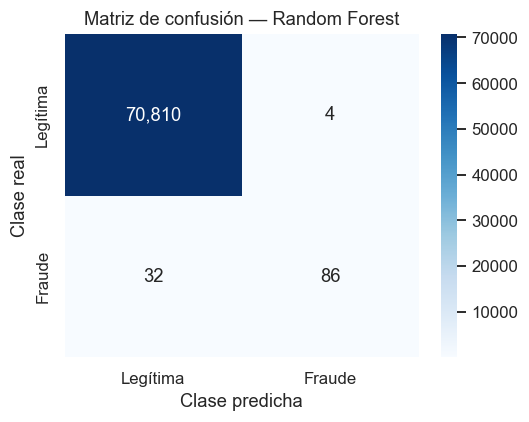

Gráfico guardado en /reports/05_matriz_confusion.png


In [19]:
# Tabla comparativa de las tres iteraciones
tabla = pd.DataFrame(resultados)
print('Comparación de modelos:')
print(tabla.to_string(index=False))

# Modelo con mejor F1 sobre el conjunto de prueba
mejor = tabla.loc[tabla['F1 (test)'].idxmax(), 'Modelo']
print(f'\nMejor modelo por F1 (test): {mejor}')

# Matriz de confusión del mejor modelo
modelos_entrenados = {
    'Regresión Logística': log_reg,
    'Random Forest': rf,
    'Gradient Boosting': hgb,
}
y_pred_mejor = modelos_entrenados[mejor].predict(X_test)
cm = confusion_matrix(y_test, y_pred_mejor)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues',
            xticklabels=['Legítima', 'Fraude'], yticklabels=['Legítima', 'Fraude'])
plt.title(f'Matriz de confusión — {mejor}')
plt.ylabel('Clase real'); plt.xlabel('Clase predicha')
plt.tight_layout()
plt.savefig(f'{REPORTS_DIR}/05_matriz_confusion.png', bbox_inches='tight')
plt.show()
print('Gráfico guardado en /reports/05_matriz_confusion.png')

## 12. Ajuste del umbral de decisión

Por defecto, el clasificador asigna la clase positiva cuando la probabilidad estimada supera 0.5, criterio que en este problema favorece la precisión a costa del recall. Dado que en la detección de fraude no detectar un caso puede resultar más costoso que una falsa alarma, se ajusta el umbral de decisión del Random Forest.

Para no sesgar la evaluación, el umbral se selecciona **usando únicamente el conjunto de entrenamiento**, mediante validación cruzada (probabilidades *out-of-fold*, es decir, cada probabilidad proviene de un modelo que no vio esa observación). Se elige el umbral que maximiza el F1 y, una vez fijado, se aplica al conjunto de prueba para reportar las métricas finales, que de este modo no intervienen en la elección.

Umbral seleccionado (máximo F1 en validación cruzada del train): 0.25


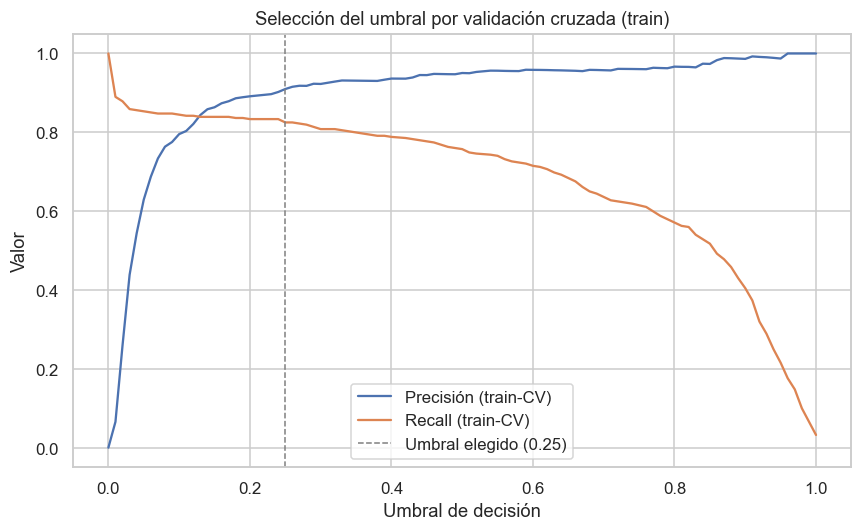


Test con umbral=0.25:  precisión=0.910  recall=0.771  F1=0.835


In [20]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve

# --- Selección del umbral usando SOLO el train (probabilidades out-of-fold) ---
# Cada probabilidad proviene de un modelo que no vio esa fila: no hay fuga de datos.
proba_oof = cross_val_predict(rf, X_train, y_train, cv=cv,
                              method='predict_proba', n_jobs=-1)[:, 1]

# Se busca el umbral que maximiza el F1 sobre el conjunto de entrenamiento
umbrales = np.arange(0.05, 0.96, 0.05)
f1_por_umbral = [f1_score(y_train, (proba_oof >= t).astype(int)) for t in umbrales]
UMBRAL = round(float(umbrales[int(np.argmax(f1_por_umbral))]), 2)
print(f'Umbral seleccionado (máximo F1 en validación cruzada del train): {UMBRAL}')

# Curva precisión/recall frente al umbral (sobre el train, donde se decide)
prec, rec, thr = precision_recall_curve(y_train, proba_oof)
plt.figure(figsize=(8, 5))
plt.plot(thr, prec[:-1], label='Precisión (train-CV)')
plt.plot(thr, rec[:-1], label='Recall (train-CV)')
plt.axvline(UMBRAL, color='gray', ls='--', lw=1, label=f'Umbral elegido ({UMBRAL})')
plt.xlabel('Umbral de decisión'); plt.ylabel('Valor')
plt.title('Selección del umbral por validación cruzada (train)')
plt.legend(); plt.tight_layout()
plt.savefig(f'{REPORTS_DIR}/06_umbral_precision_recall.png', bbox_inches='tight')
plt.show()

# --- Evaluación FINAL en el test con el umbral YA fijado ---
proba_test = rf.predict_proba(X_test)[:, 1]
y_pred_umbral = (proba_test >= UMBRAL).astype(int)
print(f'\nTest con umbral={UMBRAL}:  '
      f'precisión={precision_score(y_test, y_pred_umbral):.3f}  '
      f'recall={recall_score(y_test, y_pred_umbral):.3f}  '
      f'F1={f1_score(y_test, y_pred_umbral):.3f}')